In [19]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [20]:
#filter for the job titles and country
df_IND = df[(df['job_country'] == 'India')].dropna(subset=['salary_year_avg'])

In [21]:
job_titles = df_IND['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [22]:
df_IND_top6 = df_IND[df_IND['job_title_short'].isin(job_titles)]

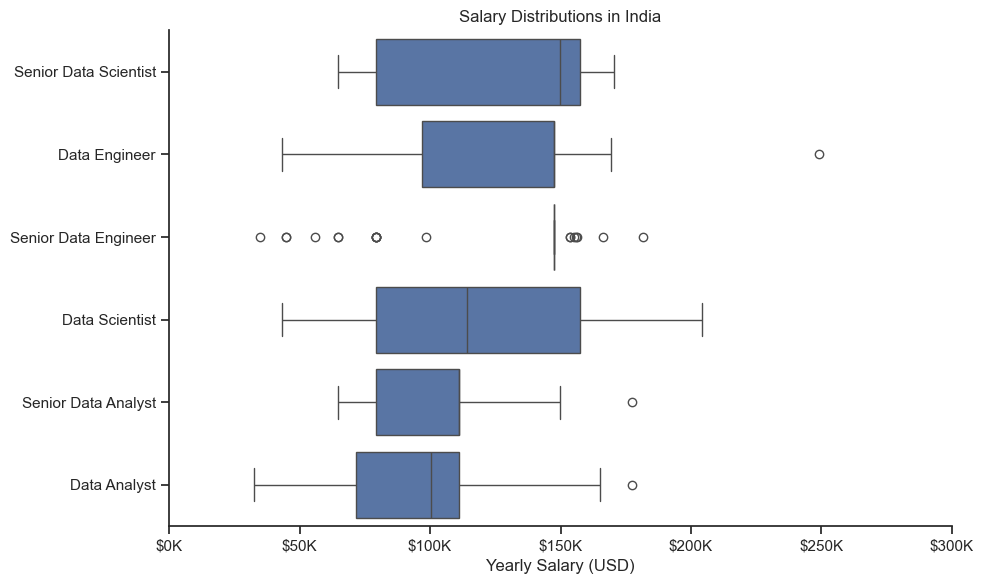

In [23]:


# Top 6 job titles
job_titles = [
    'Data Analyst',
    'Senior Data Analyst',
    'Data Engineer',
    'Senior Data Engineer',
    'Data Scientist',
    'Senior Data Scientist'
]

# Filter India jobs
df_IND_top6 = df_IND[df_IND['job_title_short'].isin(job_titles)].copy()

# Remove rows with missing salaries
df_IND_top6 = df_IND_top6.dropna(subset=['salary_year_avg'])

# Order job titles by median salary (highest to lowest)
job_order = (
    df_IND_top6.groupby('job_title_short')['salary_year_avg']
    .median()
    .sort_values(ascending=False)
    .index
)

# Plot style
sns.set_theme(style='ticks')

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_IND_top6,
    x='salary_year_avg',
    y='job_title_short',
    order=job_order
)

plt.title('Salary Distributions in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')

# Format x-axis as $K
ax = plt.gca()

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'${int(x/1000)}K'
    )
)

# Set axis limit to 300K
plt.xlim(0, 300000)

# Show ticks every 50K
plt.xticks(range(0, 300001, 50000))

sns.despine()

plt.tight_layout()

plt.show()

Investigate Median salary vs Skills for Data Analysts

In [24]:
df_DA_IND = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

In [25]:
df_DA_IND = df_DA_IND.explode('job_skills')

df_DA_IND[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


In [26]:
df_DA_top_pay = (
    df_DA_IND.groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='median', ascending=False)
)

df_DA_top_pay

,count,median
job_skills,,
postgresql,1,165000.0
pyspark,1,165000.0
gitlab,1,165000.0
linux,1,165000.0
mysql,1,165000.0
...,...,...
t-sql,1,64600.0
git,3,53014.0
bitbucket,1,53014.0


In [27]:
# Data Analyst jobs in India
df_DA_IND = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'India')
].copy()

# Remove rows with missing salaries
df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

# One skill per row
df_DA_IND = df_DA_IND.explode('job_skills')

# Skill count and median salary
df_DA_skills = (
    df_DA_IND.groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='count', ascending=False)
)

# Display top skills
df_DA_skills.head(10)

,count,median
job_skills,,
sql,46,96050.0
excel,39,98500.0
python,36,96050.0
tableau,20,108087.5
r,18,79200.0
power bi,17,111175.0
azure,15,93600.0
aws,12,79200.0
oracle,11,79200.0


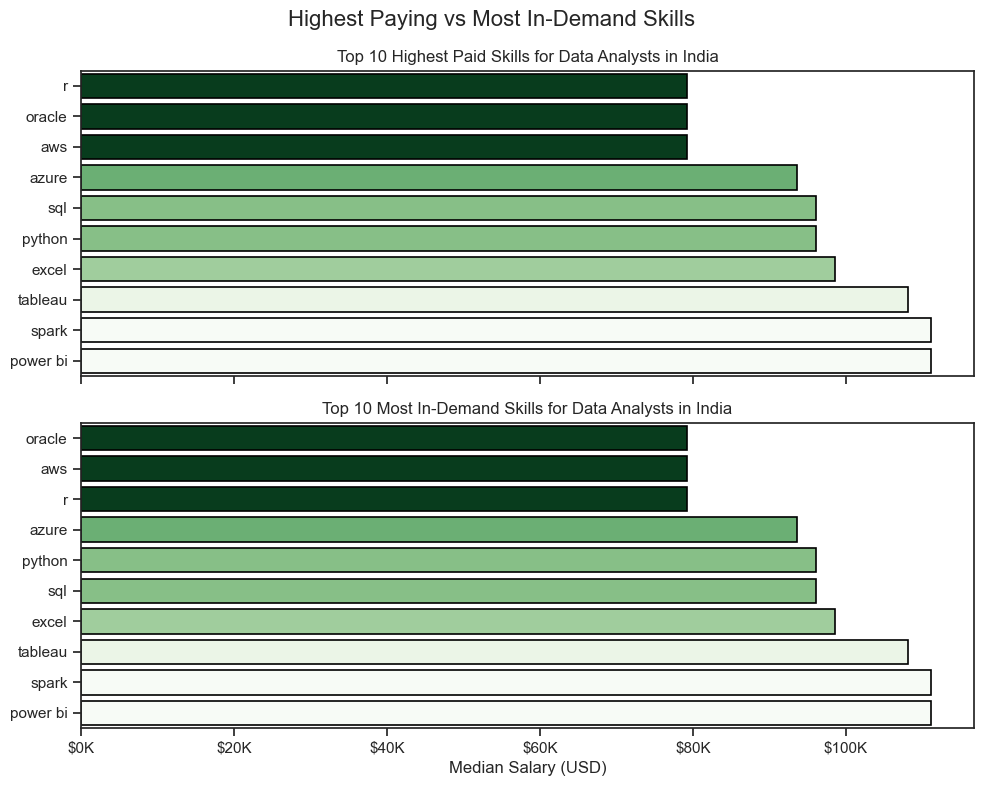

In [35]:

# DATA ANALYST JOBS - INDIA

df_DA_IND = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'India')
].copy()

df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

# explode skills
df_DA_IND = df_DA_IND.explode('job_skills')

# -------------------------
# TOP PAYING SKILLS
# -------------------------

df_DA_skills = (
    df_DA_IND
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
)

# minimum demand filter
df_DA_skills = df_DA_skills[df_DA_skills['count'] > 10]

df_DA_top_pay = (
    df_DA_skills
    .sort_values('median', ascending=False)
    .head(10)
)

# -------------------------
# MOST DEMANDED SKILLS
# -------------------------

df_DA_top_demand = (
    df_DA_skills
    .sort_values('count', ascending=False)
    .head(10)
)

# sort by salary for cleaner visualization
df_DA_top_demand = (
    df_DA_top_demand
    .sort_values('median', ascending=False)
)

# -------------------------
# PLOT
# -------------------------

sns.set_theme(style='ticks')

fig, ax = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True
)

# Top Paying Skills
sns.barplot(
    data=df_DA_top_pay,
    x='median',
    y=df_DA_top_pay.index,
    hue='median',
    palette='Greens_r',
    legend=False,
    edgecolor='black',
    linewidth=1.2,
    ax=ax[0]
)

ax[0].invert_yaxis()
ax[0].set_title(
    'Top 10 Highest Paid Skills for Data Analysts in India'
)
ax[0].set_xlabel('')
ax[0].set_ylabel('')

# Most In-Demand Skills
sns.barplot(
    data=df_DA_top_demand,
    x='median',
    y=df_DA_top_demand.index,
    hue='median',
    palette='Greens_r',
    legend=False,
    edgecolor='black',
    linewidth=1.2,
    ax=ax[1]
)

ax[1].invert_yaxis()
ax[1].set_title(
    'Top 10 Most In-Demand Skills for Data Analysts in India'
)
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')

# Currency formatting
for axis in ax:
    axis.xaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, pos: f'${int(x/1000)}K'
        )
    )

fig.suptitle(
    'Highest Paying vs Most In-Demand Skills',
    fontsize=16
)

fig.tight_layout()
plt.show()